# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV71"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv71')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv71/lv71-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV71,gene_band
0,SFTPD,6.959888,10q22.3
1,AGER,6.764971,6p21.32
2,NAPSA,5.607627,19q13.33
3,ABCA3,4.935697,16p13.3
4,CACNA2D2,4.658913,3p21.31
5,CYP4B1,4.620723,1p33
6,LAMP3,2.793338,3q27.1
7,VIPR1,2.701123,3p22.1
8,ATP11A,2.551970,13q34
9,CTSH,2.442613,15q25.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 16:43:39,090 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 16:43:39,090 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP058237, SRP006575, SRP012656, SRP041538, SRP063838, SRP061207, SRP033095, SRP010166, SRP032833, SRP007338, SRP049097, SRP067469, SRP052491, SRP019936, SRP019807, SRP006676, SRP065491, SRP052056, SRP057196, SRP050499, SRP066834, SRP055513, SRP027530, SRP042161, SRP045294, SRP055569, SRP051249, SRP057586, SRP060416, SRP002326, SRP039552, SRP047192, SRP003726, SRP064464, SRP064259, SRP059732, SRP018359, SRP050087, SRP032789, SRP060355, SRP042620, SRP027364, SRP044042, SRP016140, 

In [12]:
lv_data.shape

(5078, 70)

In [13]:
lv_data.head()

tissue               cell type  \
project   run                                                               
SRP058237 SRR2016920  Normal adjacent lung tissue  epithelial cells (Epi)   
          SRR2016919  Normal adjacent lung tissue  epithelial cells (Epi)   
          SRR2016918  Normal adjacent lung tissue  epithelial cells (Epi)   
          SRR2016917  Normal adjacent lung tissue       neutrophils (Neu)   
          SRR2016916  Normal adjacent lung tissue       neutrophils (Neu)   

                     cell line developmental stage disease status  \
project   run                                                       
SRP058237 SRR2016920       NaN                 NaN            NaN   
          SRR2016919       NaN                 NaN            NaN   
          SRR2016918       NaN                 NaN            NaN   
          SRR2016917       NaN                 NaN            NaN   
          SRR2016916       NaN                 NaN            NaN   

                     tissue archive method disease patient tissue type Stage  \
project   run                                                                  
SRP058237 SRR2016920                   NaN     NaN     NaN         NaN   NaN   
          SRR2016919                   NaN     NaN     NaN         NaN   NaN   
          SRR2016918                   NaN     NaN     NaN         NaN   NaN   
          SRR2016917                   NaN     NaN     NaN         NaN   NaN   
          SRR2016916                   NaN     NaN     NaN         NaN   NaN   

                      ... ercc_mix ercc_dilution tumor subpopulation  \
project   run         ...                                              
SRP058237 SRR2016920  ...      NaN           NaN                 NaN   
          SRR2016919  ...      NaN           NaN                 NaN   
          SRR2016918  ...      NaN           NaN                 NaN   
          SRR2016917  ...      NaN           NaN                 NaN   
          SRR2016916  ...      NaN           NaN                 NaN   

                     tumor state cell storage sequenced molecule tumor type  \
project   run                                                                 
SRP058237 SRR2016920         NaN          NaN                NaN        NaN   
          SRR2016919         NaN          NaN                NaN        NaN   
          SRR2016918         NaN          NaN                NaN        NaN   
          SRR2016917         NaN          NaN                NaN        NaN   
          SRR2016916         NaN          NaN                NaN        NaN   

                     pretreatment grade      LV71  
project   run                                      
SRP058237 SRR2016920          NaN   NaN  2.418066  
          SRR2016919          NaN   NaN  1.820301  
          SRR2016918          NaN   NaN  1.828769  
          SRR2016917          NaN   NaN  0.148071  
          SRR2016916          NaN   NaN  0.576117  

[5 rows x 70 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

disease status           0.288650
disease                  0.264151
patient                  0.264151
smoker                   0.264151
disease state            0.136162
tissue type              0.124958
tissue                   0.096173
tissue archive method    0.065769
gender                   0.062255
demographic group        0.057203
phenotype                0.057203
passages                 0.053455
kras status              0.051928
age                      0.047232
sampling time            0.045491
localication             0.043694
donor                    0.043694
time of analysis         0.043694
library type             0.043279
read length              0.043279
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue type    0.124958
tissue         0.096173
cell type      0.007777
cell line      0.001174
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue type",
    "tissue",
    "cell type",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue type                         tissue  \
project   run                                                     
SRP058237 SRR2016920         NaN    Normal adjacent lung tissue   
          SRR2016918         NaN    Normal adjacent lung tissue   
          SRR2016919         NaN    Normal adjacent lung tissue   
SRP006575 SRR537108          NaN                           lung   
          SRR537107          NaN                           lung   
SRP012656 SRR493954       normal                            NaN   
          SRR493953       normal                            NaN   
SRP041538 SRR1265634         NaN                           lung   
          SRR1265585         NaN                           lung   
SRP063838 SRR2444093         NaN  idiopathic pulmonary fibrosis   
SRP061207 SRR2103638         NaN                           lung   
SRP041538 SRR1265630         NaN                           lung   
          SRR1265676         NaN                           lung   
          SRR1265547         NaN                           lung   
SRP012656 SRR493946       normal                            NaN   
          SRR493945       normal                            NaN   
SRP041538 SRR1265613         NaN                           lung   
          SRR1265614         NaN                           lung   
SRP006575 SRR537106          NaN                           lung   
SRP041538 SRR1265499         NaN                           lung   
          SRR1265594         NaN                           lung   
          SRR1265516         NaN                           lung   
SRP012656 SRR493958       normal                            NaN   
          SRR493957       normal                            NaN   
SRP041538 SRR1265515         NaN                           lung   

                                   cell type cell line      LV71  
project   run                                                     
SRP058237 SRR2016920  epithelial cells (Epi)       NaN  2.418066  
          SRR2016918  epithelial cells (Epi)       NaN  1.828769  
          SRR2016919  epithelial cells (Epi)       NaN  1.820301  
SRP006575 SRR537108                      NaN       NaN  1.682582  
          SRR537107                      NaN       NaN  1.594361  
SRP012656 SRR493954                      NaN       NaN  1.446472  
          SRR493953                      NaN       NaN  1.444617  
SRP041538 SRR1265634                     NaN       NaN  1.383286  
          SRR1265585                     NaN       NaN  1.379233  
SRP063838 SRR2444093                     NaN       NaN  1.373114  
SRP061207 SRR2103638                     NaN       NaN  1.367464  
SRP041538 SRR1265630                     NaN       NaN  1.356874  
          SRR1265676                     NaN       NaN  1.343720  
          SRR1265547                     NaN       NaN  1.326976  
SRP012656 SRR493946                      NaN       NaN  1.316323  
          SRR493945                      NaN       NaN  1.315039  
SRP041538 SRR1265613                     NaN       NaN  1.295095  
          SRR1265614                     NaN       NaN  1.290602  
SRP006575 SRR537106                      NaN       NaN  1.290435  
SRP041538 SRR1265499                     NaN       NaN  1.290195  
          SRR1265594                     NaN       NaN  1.289007  
          SRR1265516                     NaN       NaN  1.280021  
SRP012656 SRR493958                      NaN       NaN  1.277137  
          SRR493957                      NaN       NaN  1.274951  
SRP041538 SRR1265515                     NaN       NaN  1.270049

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue type tissue cell type cell line      LV71
project   run                                                        
SRP041538 SRR1265602         NaN   lung       NaN       NaN  1.262518
          SRR1265509         NaN   lung       NaN       NaN  1.257810
          SRR1265573         NaN   lung       NaN       NaN  1.256318
SRP012656 SRR493941       normal    NaN       NaN       NaN  1.253232
          SRR493942       normal    NaN       NaN       NaN  1.252572
SRP041538 SRR1265671         NaN   lung       NaN       NaN  1.235635
          SRR1265563         NaN   lung       NaN       NaN  1.235128
          SRR1265558         NaN   lung       NaN       NaN  1.234469
          SRR1265587         NaN   lung       NaN       NaN  1.225726
          SRR1265555         NaN   lung       NaN       NaN  1.225708
          SRR1265528         NaN   lung       NaN       NaN  1.218141
          SRR1265542         NaN   lung       NaN       NaN  1.217947
          SRR1265535         NaN   lung       NaN       NaN  1.216095
          SRR1265633         NaN   lung       NaN       NaN  1.210528
          SRR1265655         NaN   lung       NaN       NaN  1.203381
          SRR1265556         NaN   lung       NaN       NaN  1.201779
          SRR1265568         NaN   lung       NaN       NaN  1.197757
          SRR1265669         NaN   lung       NaN       NaN  1.193190
          SRR1265559         NaN   lung       NaN       NaN  1.189453
          SRR1265531         NaN   lung       NaN       NaN  1.182950
          SRR1265507         NaN   lung       NaN       NaN  1.182021
          SRR1265605         NaN   lung       NaN       NaN  1.180179
          SRR1265564         NaN   lung       NaN       NaN  1.172518
          SRR1265561         NaN   lung       NaN       NaN  1.171629
          SRR1265621         NaN   lung       NaN       NaN  1.169019

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "tissue type",
    "tissue",
    "cell type",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

tissue type      LV71
project   run                                                
SRP058237 SRR2016920    Normal adjacent lung tissue  2.418066
          SRR2016918    Normal adjacent lung tissue  1.828769
          SRR2016919    Normal adjacent lung tissue  1.820301
SRP006575 SRR537108                            lung  1.682582
          SRR537107                            lung  1.594361
SRP012656 SRR493954                          normal  1.446472
          SRR493953                          normal  1.444617
SRP041538 SRR1265634                           lung  1.383286
          SRR1265585                           lung  1.379233
SRP063838 SRR2444093  idiopathic pulmonary fibrosis  1.373114
SRP061207 SRR2103638                           lung  1.367464
SRP041538 SRR1265630                           lung  1.356874
          SRR1265676                           lung  1.343720
          SRR1265547                           lung  1.326976
SRP012656 SRR493946                          normal  1.316323
          SRR493945                          normal  1.315039
SRP041538 SRR1265613                           lung  1.295095
          SRR1265614                           lung  1.290602
SRP006575 SRR537106                            lung  1.290435
SRP041538 SRR1265499                           lung  1.290195

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['Normal adjacent lung tissue',
 'lung',
 'normal',
 'idiopathic pulmonary fibrosis',
 'lung adenocarcinoma']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

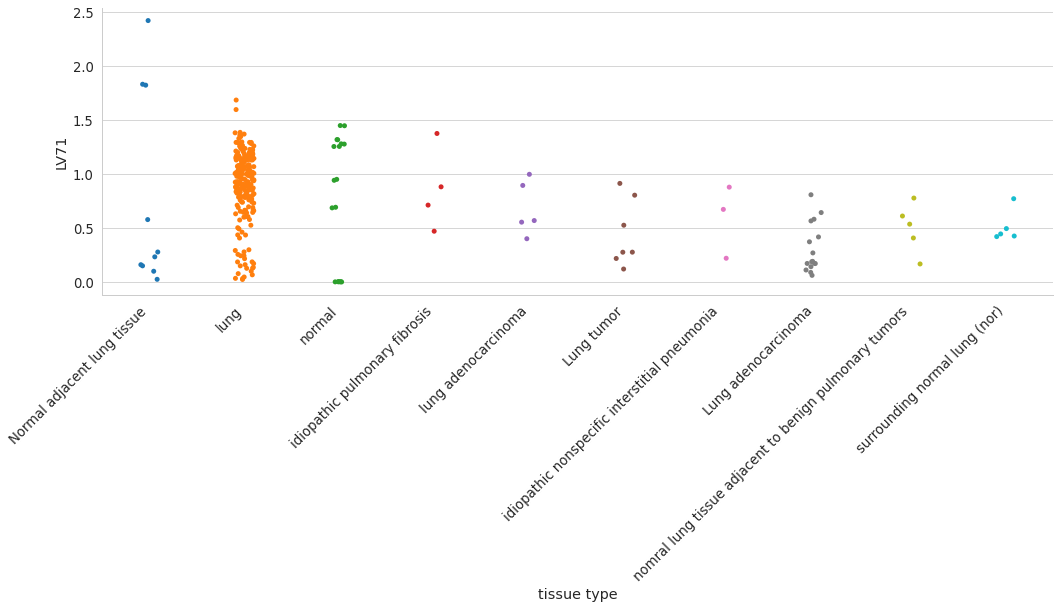

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [42]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("normal")
    ]
    display(_tmp.head(20))

tissue type      LV71
project   run                                                
SRP012656 SRR493954                          normal  1.446472
          SRR493953                          normal  1.444617
          SRR493946                          normal  1.316323
          SRR493945                          normal  1.315039
          SRR493958                          normal  1.277137
          SRR493957                          normal  1.274951
          SRR493941                          normal  1.253232
          SRR493942                          normal  1.252572
          SRR493950                          normal  0.948464
          SRR493949                          normal  0.939736
SRP032833 SRR1027988  surrounding normal lung (nor)  0.769324
SRP012656 SRR493938                          normal  0.690146
          SRR493937                          normal  0.684582
SRP032833 SRR1027985  surrounding normal lung (nor)  0.492776
SRP049097 SRR1617451                    normal lung  0.491245
          SRR1617450                    normal lung  0.488778
SRP032833 SRR1027997  surrounding normal lung (nor)  0.443310
          SRR1028000  surrounding normal lung (nor)  0.424049
          SRR1027994  surrounding normal lung (nor)  0.418608
SRP049097 SRR1617457           normal smooth muscle  0.090525

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [43]:
# what is there in these projects?
lv_data.loc[["SRP012656"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

disease patient tissue type Stage  gender  \
project   run                                                                  
SRP012656 SRR493954  Adenocarcinoma, NSCLC       6      normal    IB  female   
          SRR493953  Adenocarcinoma, NSCLC       6      normal    IB  female   
          SRR493946  Adenocarcinoma, NSCLC       4      normal    IB  female   
          SRR493945  Adenocarcinoma, NSCLC       4      normal    IB  female   
          SRR493958  Adenocarcinoma, NSCLC       8      normal    IB  female   
          SRR493957  Adenocarcinoma, NSCLC       8      normal    IB  female   
          SRR493941  Adenocarcinoma, NSCLC       3      normal    IB  female   
          SRR493942  Adenocarcinoma, NSCLC       3      normal    IB  female   
          SRR493950  Adenocarcinoma, NSCLC       5      normal    IB  female   
          SRR493949  Adenocarcinoma, NSCLC       5      normal    IB  female   
          SRR493938  Adenocarcinoma, NSCLC       1      normal    IB  female   
          SRR493937  Adenocarcinoma, NSCLC       1      normal    IB  female   
          SRR493947  Adenocarcinoma, NSCLC       4       tumor    IA  female   
          SRR493948  Adenocarcinoma, NSCLC       4       tumor    IA  female   
          SRR493959  Adenocarcinoma, NSCLC       8       tumor    IA  female   
          SRR493960  Adenocarcinoma, NSCLC       8       tumor    IA  female   
          SRR493940  Adenocarcinoma, NSCLC       1       tumor   IIA  female   
          SRR493939  Adenocarcinoma, NSCLC       1       tumor   IIA  female   
          SRR493956  Adenocarcinoma, NSCLC       6       tumor   IIB  female   
          SRR493955  Adenocarcinoma, NSCLC       6       tumor   IIB  female   
          SRR493951  Adenocarcinoma, NSCLC       5       tumor   IIA  female   
          SRR493952  Adenocarcinoma, NSCLC       5       tumor   IIA  female   
          SRR493944  Adenocarcinoma, NSCLC       3       tumor   IIB  female   
          SRR493943  Adenocarcinoma, NSCLC       3       tumor   IIB  female   
          SRR493965  Adenocarcinoma, NSCLC       4      normal    IB  female   
          SRR493961  Adenocarcinoma, NSCLC       1      normal    IB  female   
          SRR493971  Adenocarcinoma, NSCLC       8      normal    IB  female   
          SRR493966  Adenocarcinoma, NSCLC       4       tumor    IA  female   
          SRR493969  Adenocarcinoma, NSCLC       6      normal    IB  female   
          SRR493962  Adenocarcinoma, NSCLC       1       tumor   IIA  female   
          SRR493972  Adenocarcinoma, NSCLC       8       tumor    IA  female   
          SRR493970  Adenocarcinoma, NSCLC       6       tumor   IIB  female   
          SRR493963  Adenocarcinoma, NSCLC       3      normal    IB  female   
          SRR493967  Adenocarcinoma, NSCLC       5      normal    IB  female   
          SRR493968  Adenocarcinoma, NSCLC       5       tumor   IIA  female   
          SRR493964  Adenocarcinoma, NSCLC       3       tumor   IIB  female   

                          age      smoker      LV71  
project   run                                        
SRP012656 SRR493954  70 years  non-smoker  1.446472  
          SRR493953  70 years  non-smoker  1.444617  
          SRR493946  60 years  non-smoker  1.316323  
          SRR493945  60 years  non-smoker  1.315039  
          SRR493958  62 years  non-smoker  1.277137  
          SRR493957  62 years  non-smoker  1.274951  
          SRR493941  53 years  non-smoker  1.253232  
          SRR493942  53 years  non-smoker  1.252572  
          SRR493950  44 years  non-smoker  0.948464  
          SRR493949  44 years  non-smoker  0.939736  
          SRR493938  44 years  non-smoker  0.690146  
          SRR493937  44 years  non-smoker  0.684582  
          SRR493947  60 years  non-smoker  0.582171  
          SRR493948  60 years  non-smoker  0.577654  
          SRR493959  62 years  non-smoker  0.553508  
          SRR493960  62 years  non-smoker  0.552147  
          SRR493940  4

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.